In [ ]:
!pip install pymorphy3 nltk wordcloud scikit-learn matplotlib seaborn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 56.7 MB/s eta 0:00:00


## Глава 4. Анализ текстов: Вопросно-ответная система по документации
### Этап 1. Загрузка данных и первичное знакомство

В данной ячейке выполняется загрузка обучающей и валидационной выборок из файлов высокопроизводительного колоночного формата Parquet. Специфика архитектуры датасета требует извлечения текстового ответа из вложенной структуры признаков. Программный алгоритм считывает исходные словари и формирует отдельную колонку с чистым текстом ответа для обеспечения удобства последующего лингвистического анализа. В завершение скрипт выводит на экран случайный пример пары вопроса и контекстного абзаца.

In [ ]:
import pandas as pd
import numpy as np

# Пути к загруженным файлам Parquet
TRAIN_PATH = '/content/train-00000-of-00001.parquet'
VALID_PATH = '/content/train-00000-of-00001.parquet'

print("ЗАГРУЗКА ДАННЫХ")
try:
    # Загрузка данных
    df_train = pd.read_parquet(TRAIN_PATH)
    df_valid = pd.read_parquet(VALID_PATH)

    print(f"Обучающая выборка успешно загружена. Количество записей: {len(df_train)}")
    print(f"Валидационная выборка успешно загружена. Количество записей: {len(df_valid)}")

    # Извлечение чистого текста ответа из словаря Hugging Face
    def extract_first_answer(answer_dict):
        if isinstance(answer_dict, dict) and 'text' in answer_dict:
            texts = answer_dict['text']
            if len(texts) > 0:
                return texts[0]
        return ""

    df_train['answer_text'] = df_train['answers'].apply(extract_first_answer)
    df_valid['answer_text'] = df_valid['answers'].apply(extract_first_answer)

    print("\nПервые 2 строки датасета:")
    display(df_train[['context', 'question', 'answer_text']].head(2))

    print("\nСЛУЧАЙНЫЙ ПРИМЕР")
    sample = df_train.sample(1).iloc[0]
    print(f"КОНТЕКСТ:\n{sample['context']}")
    print(f"\nВОПРОС: {sample['question']}")
    print(f"ОТВЕТ: {sample['answer_text']}")

except FileNotFoundError:
    print("ОШИБКА: Файлы Parquet не найдены. Убедитесь, что они загружены в рабочую среду Colab.")

ЗАГРУЗКА ДАННЫХ
Обучающая выборка успешно загружена. Количество записей: 45328
Валидационная выборка успешно загружена. Количество записей: 45328

Первые 2 строки датасета:


,context,question,answer_text
0,В протерозойских отложениях органические остат...,чем представлены органические остатки?,известковыми выделениями сине-зелёных водорослей
1,В протерозойских отложениях органические остат...,что найдено в кремнистых сланцах железорудной ...,"нитевидные водоросли, грибные нити"



СЛУЧАЙНЫЙ ПРИМЕР
КОНТЕКСТ:
Дербент был расположен в наиболее уязвимом в стратегическом отношении месте Прикаспийского прохода, где горы Большого Кавказа ближе всего подходят к морю, оставляя лишь узкую трёхкилометровую полоску равнины. Цитадель занимает вершину ближайшего к морю холма. Путь вдоль берега преграждали две параллельные крепостные стены, примыкавшие на западе к цитадели, а восточной оконечностью уходившие в море, препятствуя обходу крепости по мелководью и образуя гавань для судов. Меж этими стенами и располагался город Дербент. К западу от цитадели на сорок километров тянулась Горная стена, призванная предотвратить обход крепости по горным долинам и перевалам.

ВОПРОС: В каком месте со стратегической точки зрения расположен Дербент?
ОТВЕТ: в наиболее уязвимом


### Этапы 2-6. Конвейер обработки естественного языка и поисковый движок

Данный программный блок реализует полный цикл подготовки текстовых данных. Скрипт последовательно очищает исходные абзацы от пунктуации и приводит токены к нижнему регистру. Далее применяется алгоритм лемматизации для приведения слов к нормальной словарной форме.

Программа подсчитывает абсолютную частоту лексем и визуализирует результаты посредством построения столбчатой диаграммы и семантического облака слов. После удаления шумовых служебных частей речи тексты векторизуются математическим методом оценки важности терминов. Итоговым результатом работы кода является запуск прототипа поискового механизма, который находит наиболее релевантный абзац для заданного вопроса на основе расчета косинусного векторного сходства.

ПОДГОТОВКА ДАННЫХ
Размер анализируемого корпуса: 1000 абзацев.

1. ОЧИСТКА ТЕКСТА
ДО очистки [0]: Славянское влияние в раннесредневековой Дакии было настолько сильным, что славянская утвердительная ...
ПОСЛЕ очистки [0]: славянское влияние в раннесредневековой дакии было настолько сильным что славянская утвердительная ч...

ДО очистки [1]: По договору между Францией и Испанией (1801) сын Фердинанда, Людовик, был сделан королём Этрурии, с ...
ПОСЛЕ очистки [1]: по договору между францией и испанией сын фердинанда людовик был сделан королём этрурии с обязательс...

2. ЛЕММАТИЗАЦИЯ (pymorphy3)
ДО лемматизации [0]: славянское влияние в раннесредневековой дакии было настолько сильным что славянская утвердительная ч...
ПОСЛЕ лемматизации [0]: славянский влияние в раннесредневековый дакий быть настолько сильный что славянский утвердительный ч...

ДО лемматизации [1]: по договору между францией и испанией сын фердинанда людовик был сделан королём этрурии с обязательс...
ПОСЛЕ лемматизации [1]:

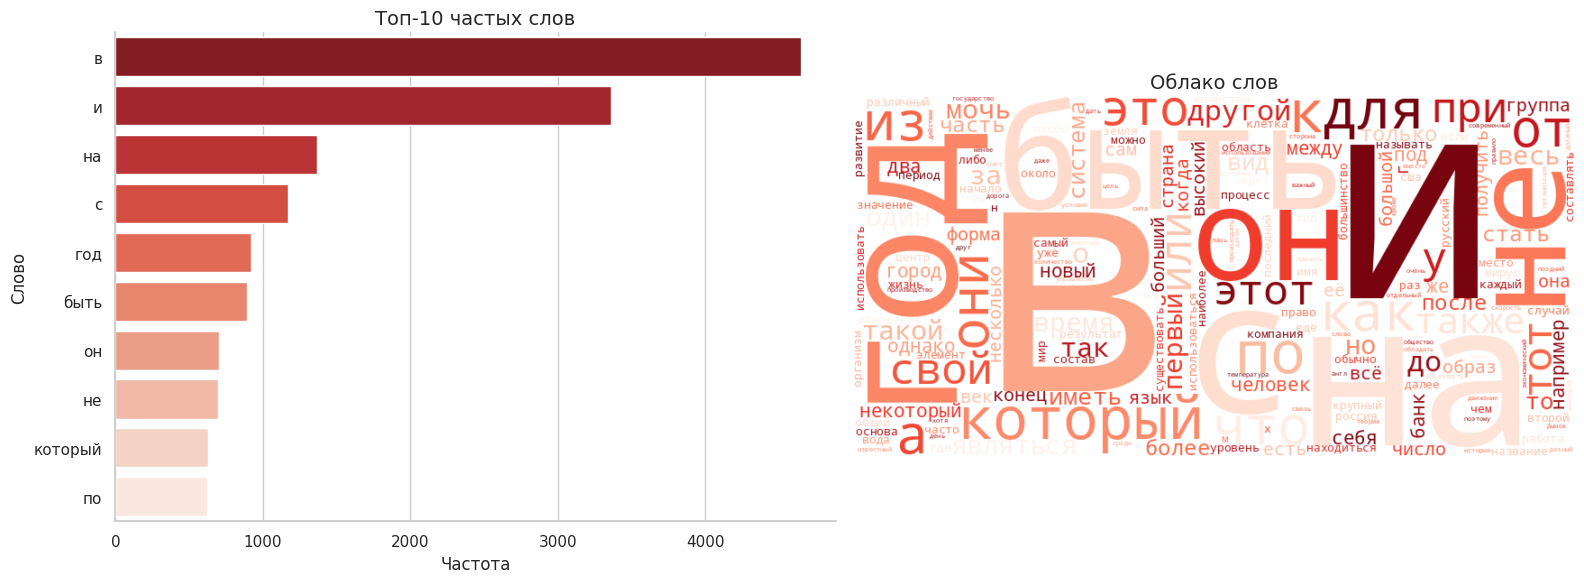


4. УДАЛЕНИЕ СТОП-СЛОВ
Топ-10 слов ПОСЛЕ удаления стоп-слов:


,Слово,Частота
0,год,921
1,который,630
2,это,446
3,свой,339
4,также,314
5,мочь,268
6,время,260
7,первый,252
8,являться,238
9,весь,235



Примеры текстов после удаления стоп-слов:
ДО удаления [0]: славянский влияние в раннесредневековый дакий быть настолько сильный что славянский утвердительный ч...
ПОСЛЕ удаления [0]: славянский влияние раннесредневековый дакий настолько сильный славянский утвердительный частица пере...

ДО удаления [1]: по договор между франция и испания сын фердинанд людовик быть сделать король этрурия с обязательство...
ПОСЛЕ удаления [1]: договор франция испания сын фердинанд людовик сделать король этрурия обязательство уступить франция ...

5. ВЫЧИСЛЕНИЕ TF-IDF
Размер матрицы TF-IDF: 1000 документов на 5000 признаков (слов).

Значения TF-IDF для первых 5 слов первого текста:
Слово: 'славянский' | TF-IDF: 0.4869
Слово: 'влияние' | TF-IDF: 0.1982
Слово: 'раннесредневековый' | Не вошло в топ-5000 признаков словаря.
Слово: 'дакий' | TF-IDF: 0.2903
Слово: 'настолько' | TF-IDF: 0.1342

6. ИНФОРМАЦИОННЫЙ ПОИСК
ЗАПРОС: Какой битрейд сжатого видео?
РЕЗУЛЬТАТ №1 (Совпадение: 0.4365)
ТЕКСТ: Для воспроизведен

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sb
import re
import nltk
from nltk.corpus import stopwords
import pymorphy3
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
from wordcloud import WordCloud

# Инициализация
nltk.download('stopwords', quiet=True)
russian_stopwords = set(stopwords.words('russian'))
morph = pymorphy3.MorphAnalyzer()
sb.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})

print("ПОДГОТОВКА ДАННЫХ")
# Берем 1000 случайных текстов для ускорения обработки
df_sample = df_train.sample(1000, random_state=42).reset_index(drop=True)
print(f"Размер анализируемого корпуса: {len(df_sample)} абзацев.\n")

# ШАГ 1. ОЧИСТКА ТЕКСТА
print("1. ОЧИСТКА ТЕКСТА")
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^а-яёa-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_sample['cleaned_text'] = df_sample['context'].apply(clean_text)

for i in range(2):
    print(f"ДО очистки [{i}]: {df_sample['context'].iloc[i][:100]}...")
    print(f"ПОСЛЕ очистки [{i}]: {df_sample['cleaned_text'].iloc[i][:100]}...\n")

# ШАГ 2. ЛЕММАТИЗАЦИЯ
print("2. ЛЕММАТИЗАЦИЯ (pymorphy3)")
def lemmatize_text(text):
    words = text.split()
    lemmatized = [morph.parse(word)[0].normal_form for word in words]
    return ' '.join(lemmatized)

df_sample['lemmatized_text'] = df_sample['cleaned_text'].apply(lemmatize_text)

for i in range(2):
    print(f"ДО лемматизации [{i}]: {df_sample['cleaned_text'].iloc[i][:100]}...")
    print(f"ПОСЛЕ лемматизации [{i}]: {df_sample['lemmatized_text'].iloc[i][:100]}...\n")

# 3. ПОДСЧЕТ ЧАСТОТЫ СЛОВ И ОБЛАКО
print("3. ЧАСТОТА СЛОВ И ОБЛАКО")
all_lemmatized_words = ' '.join(df_sample['lemmatized_text']).split()
word_counts_raw = Counter(all_lemmatized_words)
top_10_raw = pd.DataFrame(word_counts_raw.most_common(10), columns=['Слово', 'Частота'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Столбчатый график Топ-10
sb.barplot(data=top_10_raw, x='Частота', y='Слово', hue='Слово', palette='Reds_r', legend=False, ax=axes[0])
axes[0].set_title('Топ-10 частых слов', fontsize=14)

# Облако слов
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds'
).generate_from_frequencies(word_counts_raw)

axes[1].imshow(wordcloud, interpolation='bilinear')
axes[1].set_title('Облако слов', fontsize=14)
axes[1].axis('off')
plt.tight_layout()
plt.show()

# ШАГ 4. УДАЛЕНИЕ СТОП-СЛОВ
print("\n4. УДАЛЕНИЕ СТОП-СЛОВ")
def remove_stopwords(text):
    words = text.split()
    filtered = [word for word in words if word not in russian_stopwords and len(word) > 2]
    return ' '.join(filtered)

df_sample['filtered_text'] = df_sample['lemmatized_text'].apply(remove_stopwords)

all_filtered_words = ' '.join(df_sample['filtered_text']).split()
word_counts_filtered = Counter(all_filtered_words)
top_10_filtered = pd.DataFrame(word_counts_filtered.most_common(10), columns=['Слово', 'Частота'])
print("Топ-10 слов ПОСЛЕ удаления стоп-слов:")
display(top_10_filtered)

print("\nПримеры текстов после удаления стоп-слов:")
for i in range(2):
    print(f"ДО удаления [{i}]: {df_sample['lemmatized_text'].iloc[i][:100]}...")
    print(f"ПОСЛЕ удаления [{i}]: {df_sample['filtered_text'].iloc[i][:100]}...\n")


# 5. ВЫЧИСЛЕНИЕ TF-IDF
print("5. ВЫЧИСЛЕНИЕ TF-IDF")
vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(df_sample['filtered_text'])

print(f"Размер матрицы TF-IDF: {tfidf_matrix.shape[0]} документов на {tfidf_matrix.shape[1]} признаков (слов).")

# Значения TF-IDF для первых 5 слов первого текста
first_text_words = df_sample['filtered_text'].iloc[0].split()[:5]
feature_names = vectorizer.get_feature_names_out()

print("\nЗначения TF-IDF для первых 5 слов первого текста:")
for word in first_text_words:
    if word in feature_names:
        word_idx = np.where(feature_names == word)[0][0]
        score = tfidf_matrix[0, word_idx]
        print(f"Слово: '{word}' | TF-IDF: {score:.4f}")
    else:
        print(f"Слово: '{word}' | Не вошло в топ-5000 признаков словаря.")

# 6. ИНФОРМАЦИОННЫЙ ПОИСК
print("\n6. ИНФОРМАЦИОННЫЙ ПОИСК")
def search_corpus(query, vectorizer, tfidf_matrix, df, top_k=3):
    # Подготовка запроса
    cleaned = clean_text(query)
    lemmatized = lemmatize_text(cleaned)
    filtered_query = remove_stopwords(lemmatized)

    query_vector = vectorizer.transform([filtered_query])
    similarities = cosine_similarity(query_vector, tfidf_matrix).flatten()

    # Получение Топ-3 индексов
    best_indices = similarities.argsort()[-top_k:][::-1]

    print(f"ЗАПРОС: {query}")
    for rank, idx in enumerate(best_indices, 1):
        score = similarities[idx]
        print(f"РЕЗУЛЬТАТ №{rank} (Совпадение: {score:.4f})")
        print(f"ТЕКСТ: {df['context'].iloc[idx][:300]}...\n")

# Берем тестовый вопрос из самого датасета
test_question = df_sample['question'].iloc[42]
search_corpus(test_question, vectorizer, tfidf_matrix, df_sample, top_k=3)